<center><H1 style = "color: green">GERMAN CREDIT RISK ANALYSIS</H1> </center>

***

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv('german_credit_data.csv')

In [3]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
df.shape

(1000, 11)

In [5]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [6]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [12]:
df = df.fillna('Unknown')
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,Unknown,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,Unknown,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,Unknown,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,Unknown,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [8]:
for col in df.columns:
    print(f'Unique values in {col}: ')
    print(df[col].unique())
    print()

Unique values in Unnamed: 0: 
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 

In [13]:
df = df.rename(columns = {'Unnamed: 0' : 'Id'})

In [10]:
df.head()

,Id,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,Unknown,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,Unknown,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Id                1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   1000 non-null   object
 6   Checking account  1000 non-null   object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [12]:
df.describe()

,Id,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [13]:
df.groupby(['Sex', 'Risk', 'Purpose']).size().reset_index(name = 'Count')

,Sex,Risk,Purpose,Count
0,female,bad,business,7
1,female,bad,car,40
2,female,bad,domestic appliances,2
3,female,bad,education,9
4,female,bad,furniture/equipment,28
5,female,bad,radio/TV,19
6,female,bad,repairs,2
7,female,bad,vacation/others,2
8,female,good,business,12
9,female,good,car,54


## <span style = "color: white"> Data Visualization </span>

Text(0, 0.5, 'Total number of credit holders')

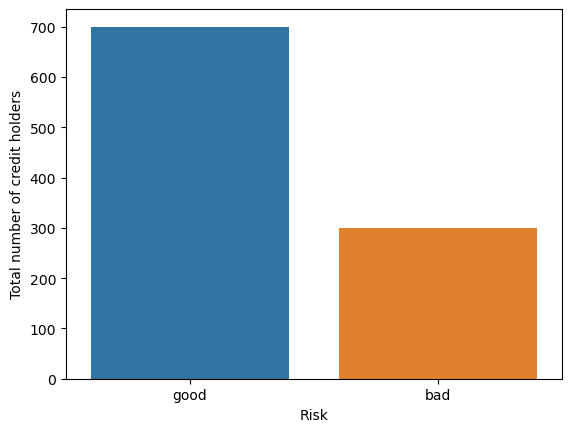

In [14]:
sns.countplot(x = 'Risk',data = df,hue = 'Risk')
plt.ylabel('Total number of credit holders')

Text(0, 0.5, 'Total number of credit holders')

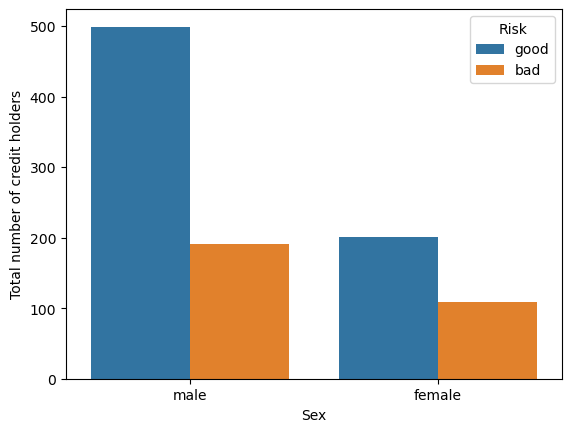

In [15]:
sns.countplot(x = 'Sex',data = df,hue ='Risk')
plt.ylabel('Total number of credit holders')

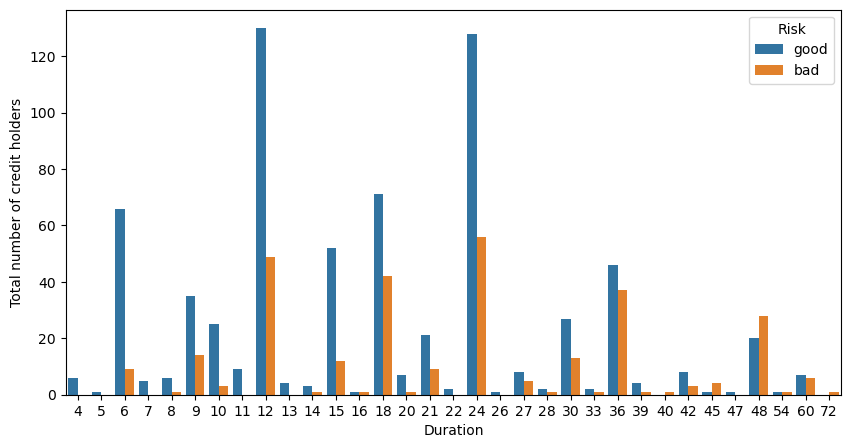

In [16]:
plt.figure(figsize=(10,5))                     

sns.countplot(data=df,
           x='Duration',
           hue='Risk')

plt.xlabel('Duration')          
plt.ylabel('Total number of credit holders')  

     

plt.show()


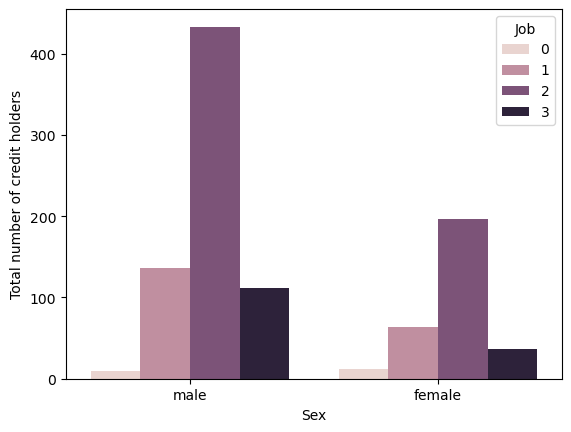

In [17]:
sns.countplot(
    data=df,
    x='Sex',
    hue='Job'
)

      
plt.ylabel('Total number of credit holders')        
plt.show()

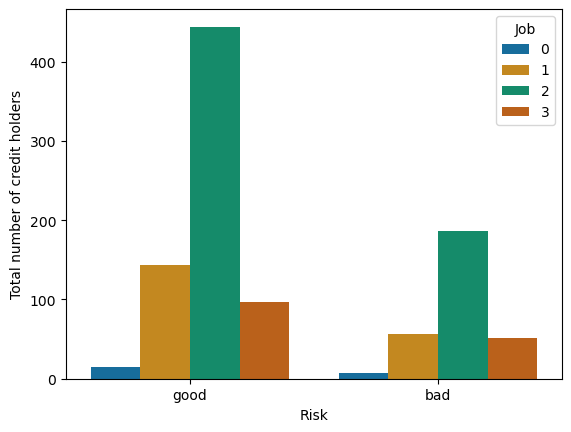

In [18]:
sns.countplot(
    data=df,
    x='Risk',palette = 'colorblind',
    hue='Job')

         
plt.ylabel('Total number of credit holders') 
plt.show()

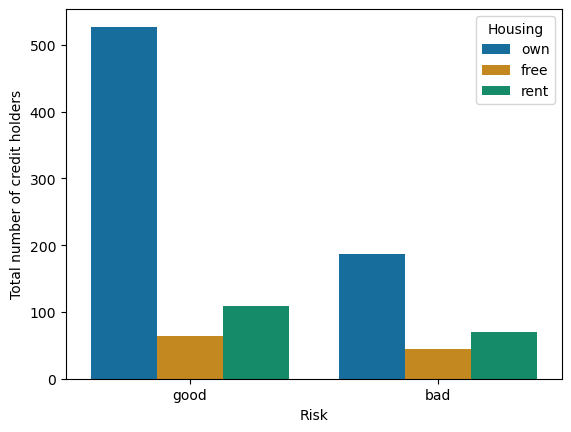

In [19]:
sns.countplot(data=df,
    x='Risk',palette = 'colorblind',
    hue='Housing')

         
plt.ylabel('Total number of credit holders') 
plt.show()

<Figure size 1000x600 with 0 Axes>

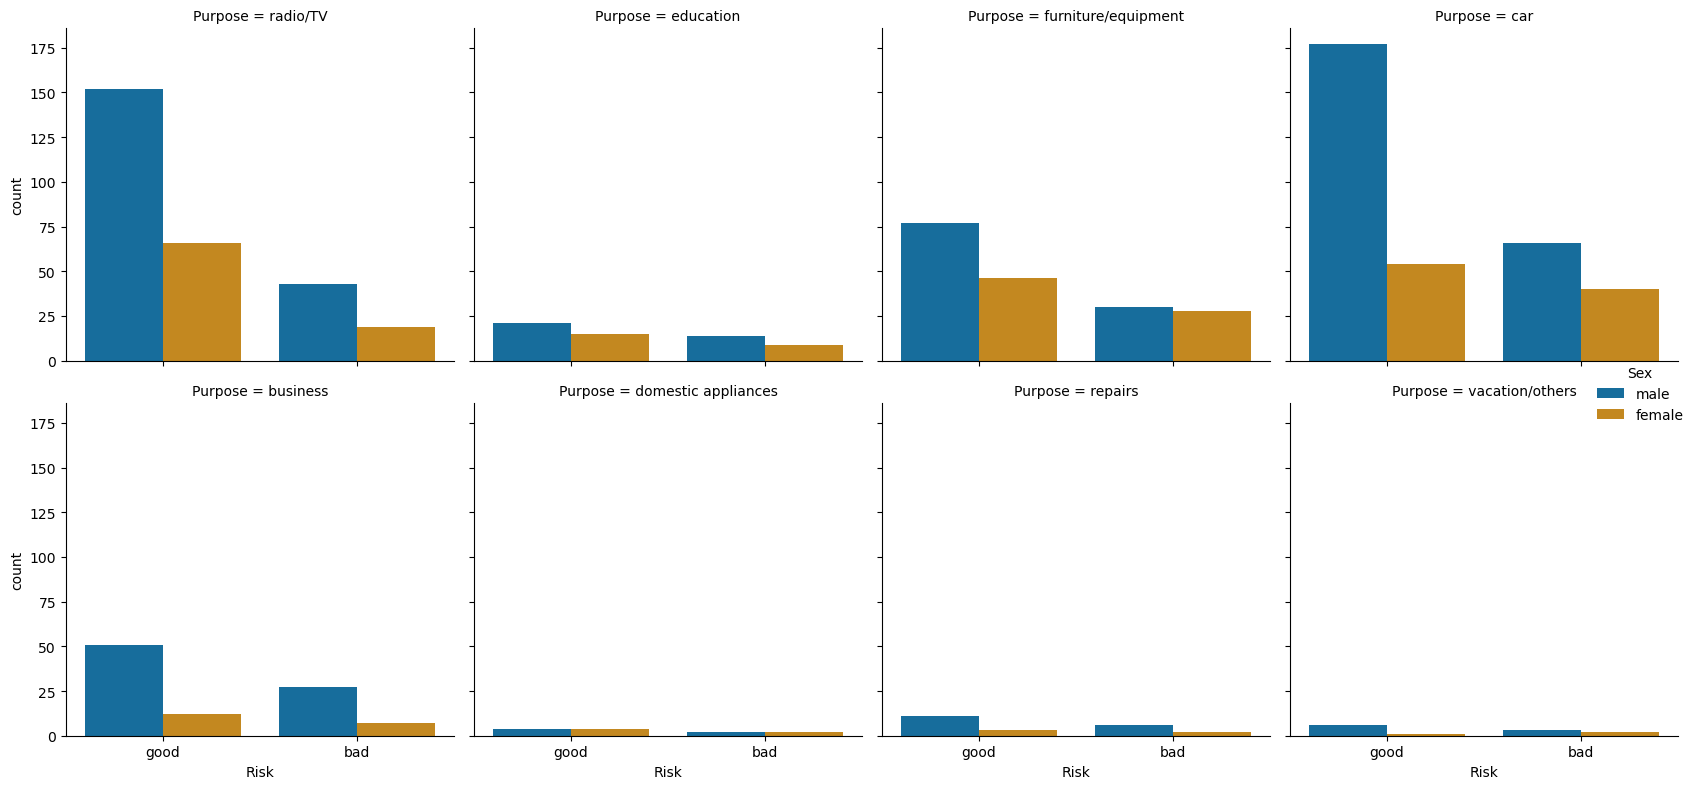

In [20]:
plt.figure(figsize = (10,6))
sns.catplot(x = 'Risk' , kind = 'count' ,
            hue = 'Sex' , data = df ,
            col = 'Purpose' ,col_wrap = 4 ,
            height = 4 ,palette = 'colorblind' )
plt.tight_layout()
plt.show()


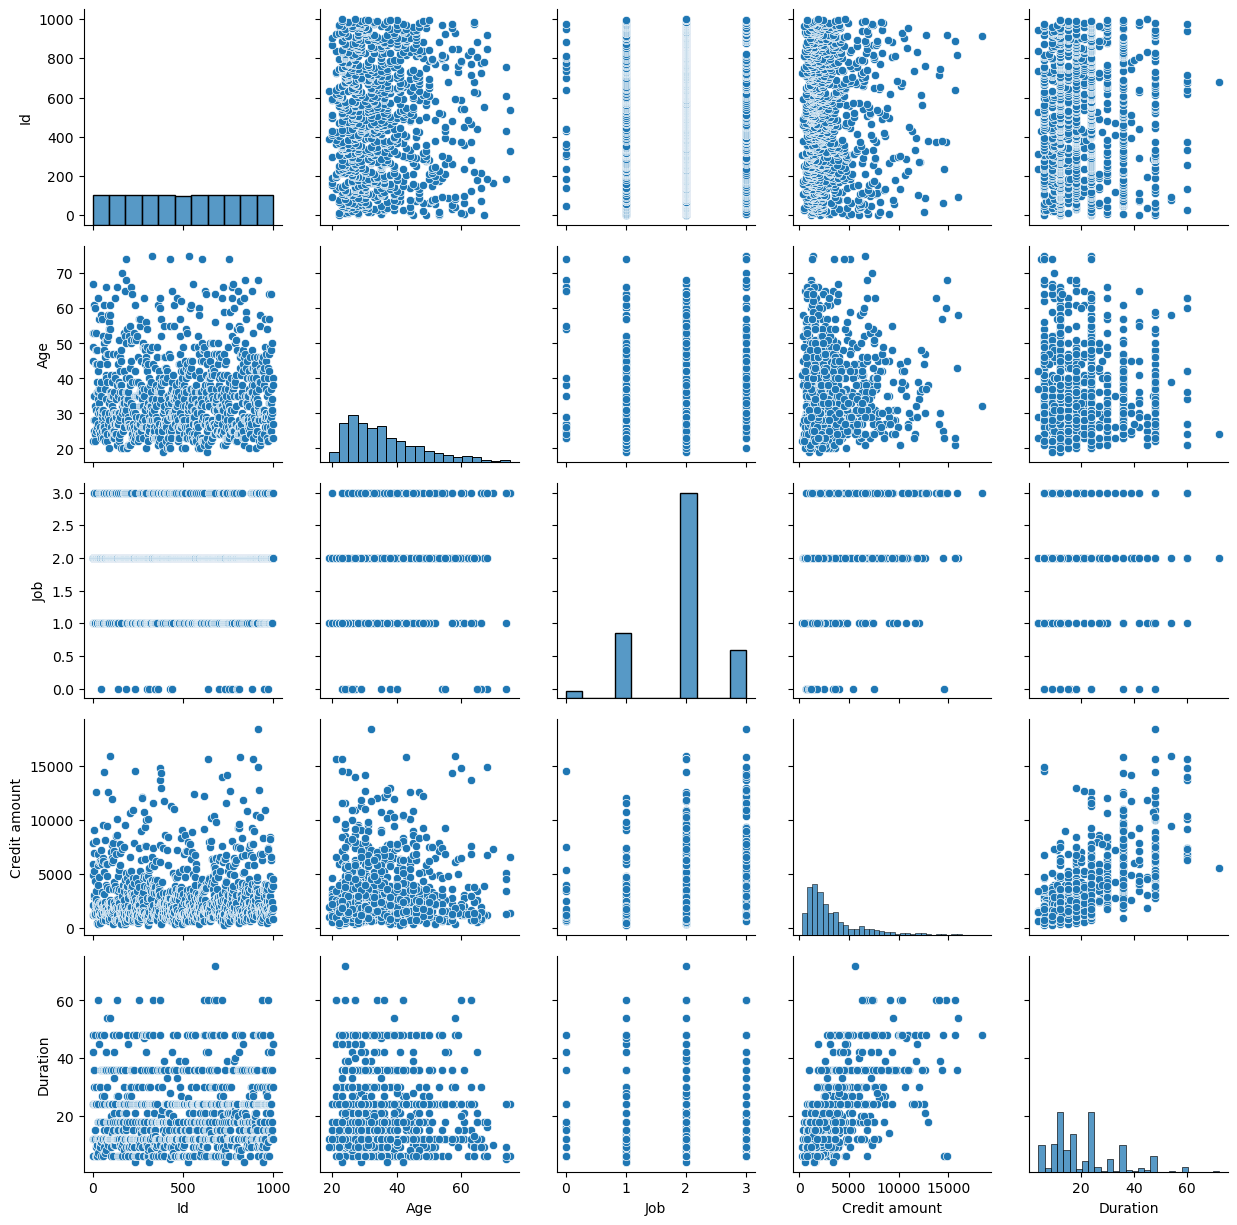

In [21]:
g = sns.PairGrid(df)

g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)

plt.show()

C:\Users\Asharaf\AppData\Local\Temp\ipykernel_13244\3713238369.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,


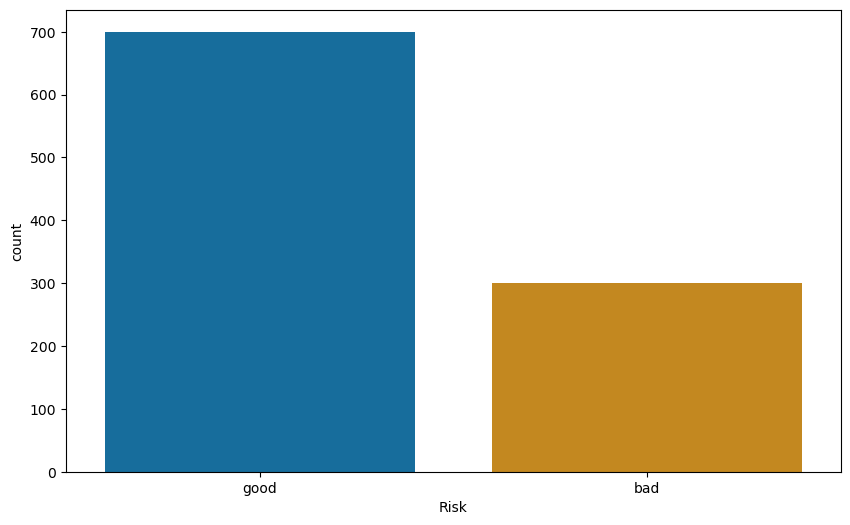

In [22]:
plt.figure(figsize = (10,6))
sns.countplot(data=df,
    x='Risk',palette = 'colorblind',)

plt.show()

## Preprocessing

In [14]:
a= pd.get_dummies(df.drop(columns = ['Id']) ,
                  columns = ['Purpose'] , dtype = int)#purpose column -- dummy

In [24]:
a.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Risk', 'Purpose_business', 'Purpose_car',
       'Purpose_domestic appliances', 'Purpose_education',
       'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs',
       'Purpose_vacation/others'],
      dtype='object')

#### Use label encoding for rest of the categorical data

In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in a.select_dtypes(include = ['object']).columns:
    a[col] = le.fit_transform(a[col])

In [26]:
print(a.select_dtypes(include = ['int']).columns)

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Risk', 'Purpose_business', 'Purpose_car',
       'Purpose_domestic appliances', 'Purpose_education',
       'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs',
       'Purpose_vacation/others'],
      dtype='object')


In [16]:
new_df = a.copy()
new_df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,1,2,1,0,1,1169,6,1,0,0,0,0,0,1,0,0
1,22,0,2,1,1,2,5951,48,0,0,0,0,0,0,1,0,0
2,49,1,1,1,1,0,2096,12,1,0,0,0,1,0,0,0,0
3,45,1,2,0,1,1,7882,42,1,0,0,0,0,1,0,0,0
4,53,1,2,0,1,1,4870,24,0,0,1,0,0,0,0,0,0


In [28]:
for col in new_df.columns:
    print(f'Unique values in {col}: ')
    print(new_df[col].unique())
    print()

Unique values in Age: 
[67 22 49 45 53 35 61 28 25 24 60 32 44 31 48 26 36 39 42 34 63 27 30 57
 33 37 58 23 29 52 50 46 51 41 40 66 47 56 54 20 21 38 70 65 74 68 43 55
 64 75 19 62 59]

Unique values in Sex: 
[1 0]

Unique values in Job: 
[2 1 3 0]

Unique values in Housing: 
[1 0 2]

Unique values in Saving accounts: 
[0 1 3 4 2]

Unique values in Checking account: 
[1 2 0 3]

Unique values in Credit amount: 
[ 1169  5951  2096  7882  4870  9055  2835  6948  3059  5234  1295  4308
  1567  1199  1403  1282  2424  8072 12579  3430  2134  2647  2241  1804
  2069  1374   426   409  2415  6836  1913  4020  5866  1264  1474  4746
  6110  2100  1225   458  2333  1158  6204  6187  6143  1393  2299  1352
  7228  2073  5965  1262  3378  2225   783  6468  9566  1961  6229  1391
  1537  1953 14421  3181  5190  2171  1007  1819  2394  8133   730  1164
  5954  1977  1526  3965  4771  9436  3832  5943  1213  1568  1755  2315
  1412 12612  2249  1108   618  1409   797  3617  1318 15945  2012  2622
 

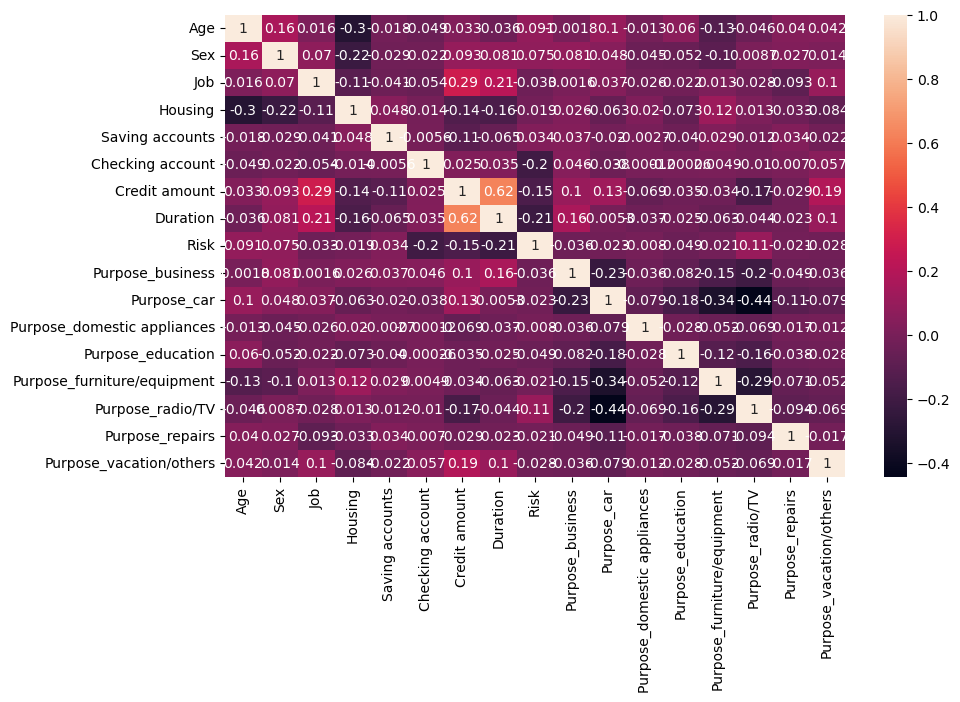

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(new_df.corr(),annot = True)
plt.show()

## Dependent(target) and Independent Variables:

In [30]:
X = new_df.drop(columns = ['Risk'])
y = new_df['Risk']

# Standardizing

In [31]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()

In [32]:
xcols = X.columns
X_std = std.fit_transform(X)
X_std = pd.DataFrame(X_std , columns = xcols)
X_std.head(3)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,2.766456,0.670280,0.146949,-0.13371,-1.231393,-0.001045,-0.745131,-1.236478,-0.327749,-0.712949,-0.110208,-0.250398,-0.470108,1.603567,-0.149983,-0.110208
1,-1.191404,-1.491914,0.146949,-0.13371,-0.196609,1.044372,0.949817,2.248194,-0.327749,-0.712949,-0.110208,-0.250398,-0.470108,1.603567,-0.149983,-0.110208
2,1.183312,0.670280,-1.383771,-0.13371,-0.196609,-1.046463,-0.416562,-0.738668,-0.327749,-0.712949,-0.110208,3.993639,-0.470108,-0.623610,-0.149983,-0.110208


#### Splitting into training and testing set

In [33]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.25 , random_state = 101)

#### Random Forest Classifier.

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.model_selection import cross_val_score

In [35]:
rfc  = RandomForestClassifier()

In [36]:
params = {'n_estimators' : list(range(1,50)) ,
          'criterion' :['gini', 'entropy'] , 
         'max_depth':[None,1,2,3]}

In [37]:
gsv = GridSearchCV(rfc, params ,cv = 5 , scoring = 'accuracy')
gsv.fit(X_train , y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 1, 2, 3],
                         'n_estimators': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                          13, 14, 15, 16, 17, 18, 19, 20, 21,
                                          22, 23, 24, 25, 26, 27, 28, 29, 30, ...]},
             scoring='accuracy')

In [38]:
gsv.score(X_train , y_train)

1.0

In [39]:
test_pred = gsv.predict(X_test)
test_pred

array([0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0])

In [40]:
gsv.score(X_test , y_test)

0.74

#### confusion matrix

In [41]:
metrics.confusion_matrix(test_pred , y_test)

array([[ 36,  17],
       [ 48, 149]])

<Axes: >

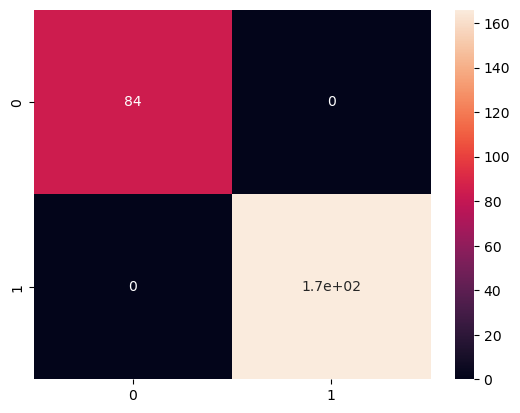

In [42]:
sns.heatmap(metrics.confusion_matrix(y_test , y_test) , annot = True)

#### cross_val_score

In [43]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

In [44]:
cross_val_score(DecisionTreeClassifier() , X , y , cv=3)

array([0.70658683, 0.67867868, 0.68168168])

#### SVM

In [45]:
from sklearn.svm import SVC
model = SVC()

In [46]:
var1 = model.fit(X_train , y_train)
var1

SVC()

#### LogisticRegression

In [47]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

var2 = model.fit(X_train , y_train)
var2


C:\Users\Asharaf\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

#### AdaBoost: Classifier

In [48]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier()

var3 = model.fit(X_train , y_train)
var3

AdaBoostClassifier()

#### scores of the different models 

In [49]:
var1.score(X_train , y_train)

0.7186666666666667

In [50]:
var2.score(X_train , y_train)

0.7106666666666667

In [51]:
var3.score(X_train , y_train)

0.7666666666666667

#### Principal Component Analysis(PCA)


In [52]:
from sklearn.decomposition import PCA

In [53]:
pca = PCA(n_components = 4)

In [54]:
X_pca = pd.DataFrame(pca.fit_transform(X))

In [55]:
from sklearn.linear_model import LogisticRegression

In [56]:
# all parameters not specified are set to their defaults
# default solver is incredibly slow thats why we change it
# solver = 'lbfgs'
model = LogisticRegression(solver = 'lbfgs')

In [57]:
model.fit(X_train , y_train)

C:\Users\Asharaf\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [58]:
test_pred = model.predict(X_test)
test_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1])

In [59]:
print(model.score(X_train , y_train))
model.score(X_test , y_test)

0.7106666666666667


0.68

In [60]:
#Confusion Matrix
from sklearn import metrics
a = metrics.confusion_matrix(test_pred , y_test)

<Axes: >

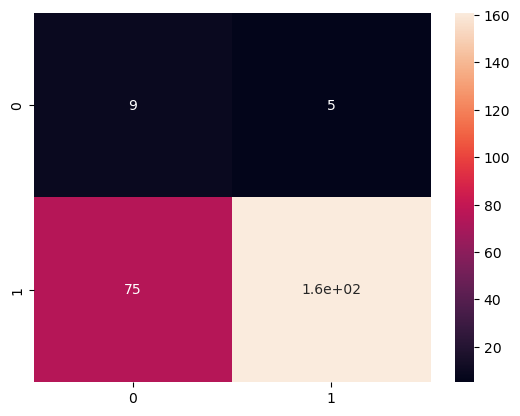

In [61]:
sns.heatmap(a , annot = True)

## Model Deployment With Tkinter

In [2]:
from tkinter import *
import joblib 

In [3]:
pipe = joblib.load('german_credit_pipeline.joblib')

In [63]:
'''from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler' , StandardScaler()),
    ('model', rfc )
])

pipe.fit(X_train , y_train)
joblib.dump(pipe ,'german_credit_pipeline.joblib')'''

['german_credit_pipeline.joblib']

In [4]:
df = pd.read_csv('german_credit_data.csv')
df = df.fillna('Unknown')
df = df.rename(columns = {'Unnamed: 0' : 'Id'})
a= pd.get_dummies(df.drop(columns = ['Id']) ,
                  columns = ['Purpose'] , dtype = int)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in a.select_dtypes(include = ['object']).columns:
    a[col] = le.fit_transform(a[col])

In [5]:
new_df = a.copy()

X = new_df.drop(columns = ['Risk'])
y = new_df['Risk']
xcols = X.columns


from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.25 , random_state = 101)

In [6]:
pipe.score(X_train , y_train)

1.0

In [8]:
new_df.head(4)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,1,2,1,0,1,1169,6,1,0,0,0,0,0,1,0,0
1,22,0,2,1,1,2,5951,48,0,0,0,0,0,0,1,0,0
2,49,1,1,1,1,0,2096,12,1,0,0,0,1,0,0,0,0
3,45,1,2,0,1,1,7882,42,1,0,0,0,0,1,0,0,0


### Predict Function

In [7]:
def predict():
    age1 = int(age.get())             
    sex = sex_var.get()
    job1 = int(job_var.get())
    housing = housing_var.get()
    saving = saving_var.get()
    check = checking_var.get()
    credit_amount1 = int(credit_amount.get())
    duration1 = int(duration.get())
    p = purpose_var.get()

    #sex encoding
    sex = 1 if sex == 'Male' else 0

    #job encoding
    
    #housing encoding
    housing_map = {
    "Free": 0,
    "Own": 1,
    "Rent": 2 }
    housing = housing_map[housing]

    #saving account encoding
    saving_map = {
        "Unknown" : 0,
        "little" : 1 ,
        "moderate" : 2 ,
        "quite rich" : 3,
        "rich" : 4}
    saving = saving_map[saving]

    #checking account encoding
    checking_map = {
        "Unknown": 0,
        "little": 1,
        "moderate": 2,
        "rich": 3
    }
    check = checking_map[check]

    
     
    # default all purpose columns = 0
    Purpose_business = 0
    Purpose_car = 0
    Purpose_domestic_appliances = 0
    Purpose_education = 0
    Purpose_furniture_equipment = 0
    Purpose_radio_TV = 0
    Purpose_repairs = 0
    Purpose_vacation_others = 0

    if p == "Purpose_business":
        Purpose_business = 1
    elif p == "Purpose_car":
        Purpose_car = 1
    elif p == "Purpose_domestic appliances":
        Purpose_domestic_appliances = 1
    elif p == "Purpose_education":
        Purpose_education = 1
    elif p == "Purpose_furniture/equipment":
        Purpose_furniture_equipment = 1
    elif p == "Purpose_radio/TV":
        Purpose_radio_TV = 1
    elif p == "Purpose_repairs":
        Purpose_repairs = 1
    elif p == "Purpose_vacation/others":
        Purpose_vacation_others = 1
    
    #input DataFrame (must match X columns order)
    input_data = pd.DataFrame([[age1, sex, job1, housing ,
                                saving , check ,
                                credit_amount1, duration1 , 
                                Purpose_business, Purpose_car,
                                Purpose_domestic_appliances, Purpose_education,
                                Purpose_furniture_equipment, Purpose_radio_TV,
                                Purpose_repairs, Purpose_vacation_others]],
                                columns = xcols)
    
    prediction = pipe.predict(input_data)

    output_entry.delete(0, END)
    
    if prediction[0] == 1:
         output_entry.insert(0, 'Good Risk') 
    elif prediction[0] == 0:
        output_entry.insert(0, 'Bad Risk') # display result in Entry box

### Tkinter window

In [8]:
window = Tk()
window.geometry('500x550')
window.title('German Credit Risk Analysis')

params = { 'font':('ink free',15,'bold') , 'fg' : "#4ce21a", 'bg' :'black', 'relief': RAISED, 'bd': 5, 'padx': 15}

Label(window, text="Age", **params).grid(row=0, column=0, padx=10, pady=5, sticky="w")
age = Entry(window , font=('ink free',15,'bold'))
age.grid(row=0, column=1, pady=5)


Label(window, text="Sex", **params).grid(row=1, column=0, padx=10, pady=5, sticky="w")
sex_frame = Frame(window, bg="#00ff9d")
sex_frame.grid(row=1, column=1, sticky="w")

sex_var = StringVar(value = 'Male')
Radiobutton(sex_frame, text='Male',  value='Male', variable = sex_var ,bg="#00ff9d").pack(side=LEFT)
Radiobutton(sex_frame, text='Female',  value='Female', variable = sex_var ,  bg="#00ff9d").pack(side=LEFT)

job_var = StringVar()
job_var.set('0')
jobs = ['0','1','2','3']
Label(window, text="Job", **params).grid(row=2, column=0, padx=10, pady=5, sticky="w")
OptionMenu(window , job_var , *jobs).grid(row=2, column=1, pady=5)

housing_var = StringVar()
housing_var.set("Own")   # default
housing = ["Own" , "Free" , "Rent"]
Label(window, text="Housing", **params).grid(row=3, column=0, padx=10, pady=5, sticky="w")
OptionMenu(window, housing_var , *housing).grid(row=3, column=1 , pady = 5)

saving_var = StringVar()
saving_var.set('little')
saving = ['Unknown', 'quite rich' ,  'rich' , 'moderate']
Label(window, text="Saving accounts", **params).grid(row=4, column=0, padx=10, pady=5, sticky="w")
OptionMenu(window, saving_var, *saving).grid(row=4, column=1 , pady = 5)

checking_var = StringVar()
checking_var.set('little')
checking = ['Unknown',  'rich' , 'moderate']
Label(window, text="Checking accounts", **params).grid(row=5, column=0, padx=10, pady=5, sticky="w")
OptionMenu(window , checking_var , *checking).grid(row = 5 , column = 1 , pady = 5)

Label(window, text="Credit amount", **params).grid(row=6, column=0, padx=10, pady=5, sticky="w")
credit_amount = Entry(window , font=('ink free',15,'bold'))
credit_amount.grid(row=6, column=1, pady=5)

Label(window, text="Duration", **params).grid(row=7, column=0, padx=10, pady=5, sticky="w")
duration = Entry(window , font=('ink free',15,'bold'))
duration.grid(row=7, column=1, pady=5)

purpose_var = StringVar()
purpose_var.set("Purpose_car")   # default
purposes = ["Purpose_business","Purpose_car","Purpose_domestic appliances","Purpose_education",
          "Purpose_furniture/equipment","Purpose_radio/TV","Purpose_repairs","Purpose_vacation/others"]
Label(window, text="Purpose", **params).grid(row=8, column=0, padx=10, pady=5, sticky="w")
OptionMenu(window, purpose_var, *purposes).grid(row=8, column=1 , pady = 5)

button = Button(window, text='Get Prediction :)', command=predict,
            font=('ink free',15,'bold','italic'), fg='#e7f20a', bg="#f25f0a")
button.grid(row=9, column=0, columnspan=2, pady=15)

output_entry = Entry(window , font=('ink free',15,'bold'))
output_entry.grid(row=10, column=0, columnspan=2, pady=5)

window.config(background="#00ff9d")
window.mainloop()

***